In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [18]:
df = pd.read_csv('../../master_datasets/crime_datasets/finaldf.csv')
# df = pd.read_csv('finaldf.csv')
df.columns

Index(['Zipcode', 'OccurredFromDate', 'NIBRS_Offense', 'Vic_Count',
       'Day_of_the_week', 'LocationType', 'Neighborhoods', 'Population(2024)'],
      dtype='object')

In [19]:
df['OccurredFromDate'] = pd.to_datetime(df['OccurredFromDate'])

# Drop rows where the date is exactly January 1, 2025
df = df[df['OccurredFromDate'].dt.date != pd.to_datetime('2025-01-01').date()]

Day Preference check


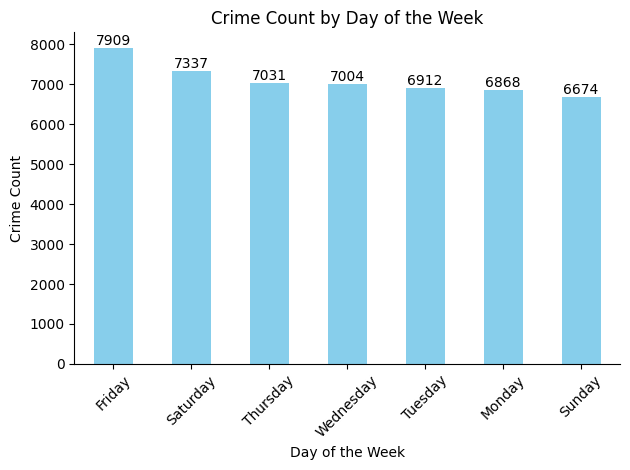

In [20]:
# Group by 'Day_of_the_week' and count the crimes
crime_count_per_day = df.groupby('Day_of_the_week').size()

# Sort in descending order
crime_count_per_day = crime_count_per_day.sort_values(ascending=False)

# Plot the bar plot
fig, ax = plt.subplots()
crime_count_per_day.plot(kind='bar', color='skyblue', ax=ax)

# Add title and labels
plt.title('Crime Count by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Crime Count')

# Add values on top of bars
for i, v in enumerate(crime_count_per_day):
    ax.text(i, v + 0.2, str(v), ha='center', va='bottom', fontsize=10)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()  # To adjust layout for better spacing
# plt.savefig("crimeday.png", dpi=300)  # Save as high-quality PNG

plt.show()

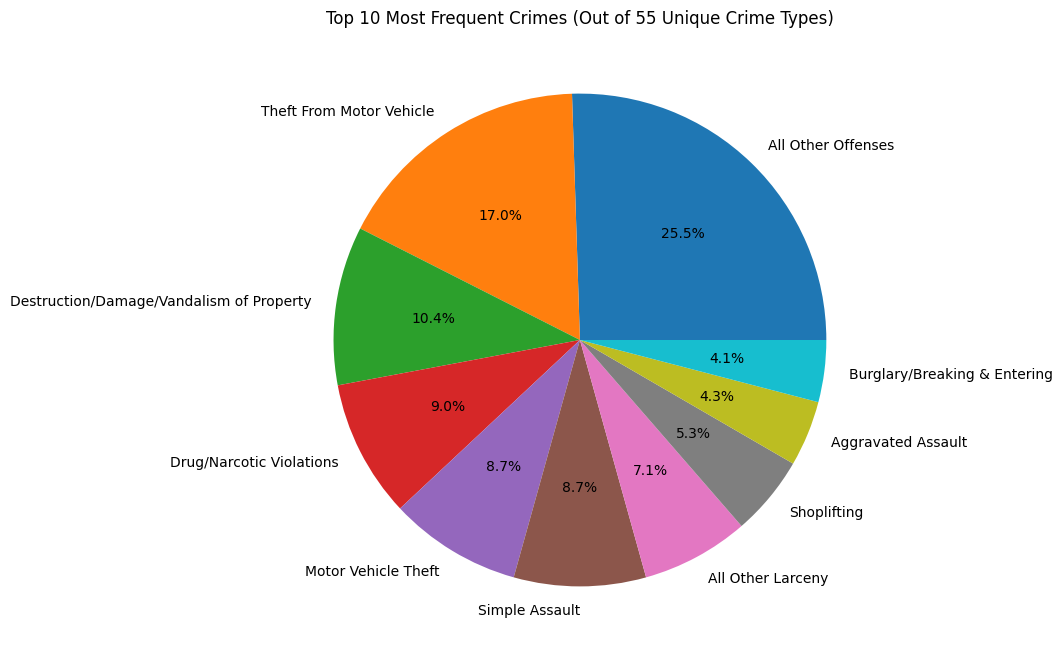

In [21]:
# Group by 'NIBRS_Offense' and count the crimes
crime_by_offense = df.groupby('NIBRS_Offense').size()

crime_by_offense.sort_values(ascending=False).head(10).plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Top 10 Most Frequent Crimes (Out of 55 Unique Crime Types)')
plt.ylabel('')

# plt.savefig("crimetypes.png", dpi=300)  # Save as high-quality PNG

plt.show()

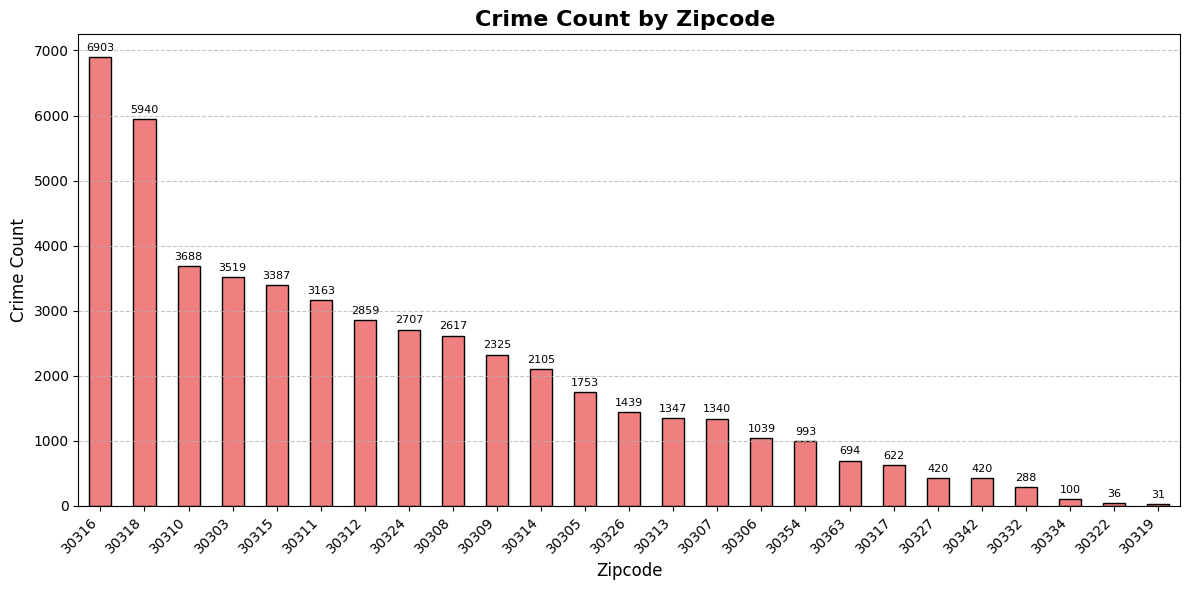

In [22]:
# Group by 'Zipcode' and count the crimes
crime_by_zipcode = df.groupby('Zipcode').size().sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
bars = crime_by_zipcode.plot(kind='bar', color='lightcoral', edgecolor='black')

# Title and labels
plt.title('Crime Count by Zipcode ', fontsize=16, fontweight='bold')
plt.xlabel('Zipcode', fontsize=12)
plt.ylabel('Crime Count', fontsize=12)

# Improve X-axis label angle and layout
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

# Optional: Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: Add value labels on top of bars
for bar in bars.containers[0]:
    height = bar.get_height()
    if height > 0:
        bars.annotate(f'{height}', xy=(bar.get_x() + bar.get_width() / 2, height),
                      xytext=(0, 3), textcoords='offset points',
                      ha='center', va='bottom', fontsize=8)

# plt.savefig("zipcrimecount'.png", dpi=300)  # Save before showing
plt.show()  

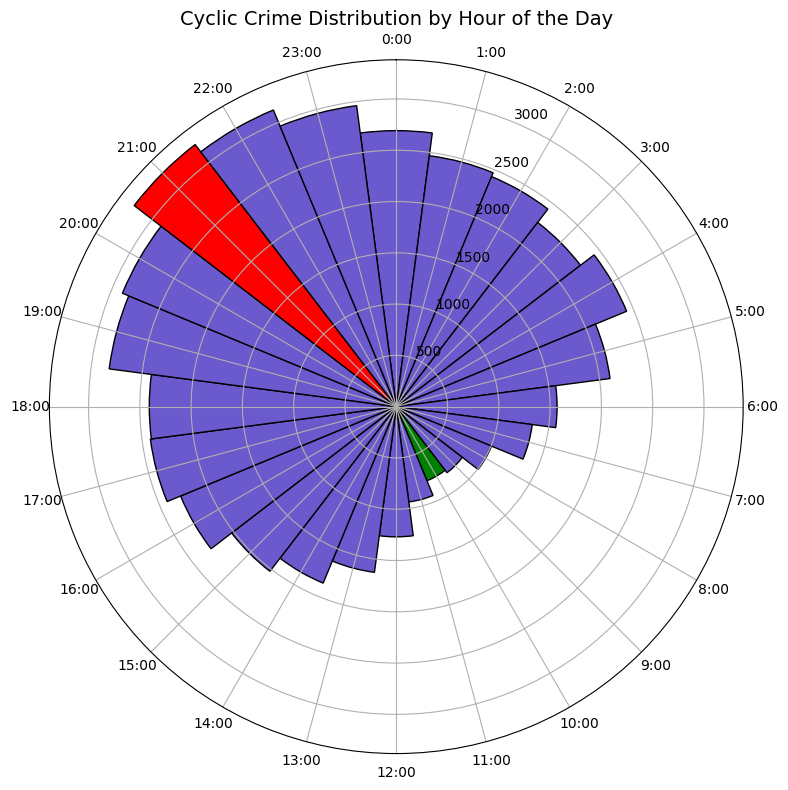

In [23]:
# Extract hour if not already done
df['Hour'] = df['OccurredFromDate'].dt.hour

# Count crimes per hour
hour_counts = df['Hour'].value_counts().sort_index()
hours = np.arange(0, 24)
counts = [hour_counts.get(hour, 0) for hour in hours]

# Identify max and min
max_count = max(counts)
min_count = min(counts)

# Assign colors based on max/min
colors = ['red' if count == max_count else 'green' if count == min_count else 'slateblue' for count in counts]

# Convert hours to radians for polar plot
theta = 2 * np.pi * hours / 24

# Plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
bars = ax.bar(theta, counts, width=2*np.pi/24, bottom=0, color=colors, edgecolor='black')

# Styling
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_xticks(2 * np.pi * np.arange(24) / 24)
ax.set_xticklabels([f"{h}:00" for h in hours])

plt.title('Cyclic Crime Distribution by Hour of the Day', fontsize=14)
plt.tight_layout()
# plt.savefig("crimelocationtyoes", dpi=300)  #  Save before showing
plt.show()  
